# GNN — TSP Benchmark

Standard TSP (no time windows, no perturbations).  
Compares the trained **GNN** against classical baselines.

| Section | Content |
|---------|--------|
| 1 | Imports & model loading |
| 2 | Baseline helpers (NN, 2-opt, brute-force optimal) |
| 3 | Benchmark n=10 — comparison with optimal |
| 4 | Benchmark n=50, n=100 |
| 5 | Results table + inference time |
| 6 | Tour visualisation |

## Section 1 — Imports & model loading

Train first if the checkpoint does not exist:
```bash
python train.py --mode tsp --n 10 --epochs 3000 --size small
python train.py --mode tsp --n 50 --epochs 3000 --size medium
```

In [34]:
import sys, os, time, glob, re, json as _json
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from itertools import permutations

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from data  import (random_instance, nn_tour_labels, two_opt_improve,
                   tour_length, greedy_decode, optimal_tour_labels)
from model import TSPGNN, MODEL_SIZES

torch.manual_seed(42)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE)

# ── Dataset directory ─────────────────────────────────────────────
_HERE        = os.path.dirname(os.path.abspath('__file__'))
DATASETS_DIR = os.path.normpath(os.path.join(_HERE, '..', '..', 'datasets'))


def discover_datasets(datasets_dir=DATASETS_DIR, max_n=None):
    """
    Return sorted list of (n, path) tuples for all tsptwd_n*.json files.
    Pass max_n=500 to exclude very large instances and keep runtime short.
    """
    result = []
    for f in sorted(glob.glob(os.path.join(datasets_dir, 'tsptwd_n*.json'))):
        m = re.search(r'tsptwd_n(\d+)\.json$', f)
        if m:
            n = int(m.group(1))
            if max_n is None or n <= max_n:
                result.append((n, f))
    return sorted(result, key=lambda x: x[0])


def load_coords_from_json(path):
    """
    Load (x, y) from a tsptwd_n*.json file.
    Returns (n_nodes, 2) float32 tensor -- depot at index 0, then clients.
    Only reads x/y: depot 'b': null is irrelevant here.
    """
    with open(path, encoding='utf-8') as fh:
        print(f'Loading coordinates from {path} ...')
        d = _json.load(fh)
    nodes = [d['depot']] + d['clients']
    return torch.tensor([[v['x'], v['y']] for v in nodes], dtype=torch.float32)


AVAILABLE = discover_datasets()   # all sizes; pass max_n=500 to cap
print(f'Found {len(AVAILABLE)} dataset(s):',
      ', '.join(f'n={n}' for n, _ in AVAILABLE))


device: cpu
Found 8 dataset(s): n=5, n=10, n=50, n=100, n=200, n=300, n=500, n=1000


In [35]:
SIZE = 'medium'          # 'small' | 'medium' | 'large'
d, L = MODEL_SIZES[SIZE]

# TSP model: node_dim=2 (x,y), edge_dim=1 (euclidean distance only)
model_tsp = TSPGNN(d=d, L=L, node_dim=2, edge_dim=1).to(DEVICE)

ckpt = f'model/gnn_{SIZE}.pt'
if os.path.exists(ckpt):
    model_tsp.load_state_dict(torch.load(ckpt, map_location='cpu'))
    print(f'Loaded {ckpt}')
else:
    print(f'WARNING: {ckpt} not found — using random weights (results meaningless)')

model_tsp.eval()
print(f'Parameters: {sum(p.numel() for p in model_tsp.parameters()):,}')

Loaded model/gnn_medium.pt
Parameters: 504,327


## Section 2 — Baseline helpers

In [36]:
def optimal_tour(coords: torch.Tensor):
    """Brute-force optimal tour — only feasible for n <= 10."""
    n = coords.shape[0]
    best_len, best_tour = float('inf'), None
    for perm in permutations(range(1, n)):
        t = [0] + list(perm)
        l = tour_length(coords, t)
        if l < best_len:
            best_len, best_tour = l, t
    return best_tour, best_len


def run_nn(coords: torch.Tensor) -> list:
    """Nearest-neighbour greedy tour."""
    dist = torch.cdist(coords, coords)
    p = 1.0 / (dist + 1e-8)
    p.fill_diagonal_(0.0)
    return greedy_decode(p, start=0)


def run_2opt(coords: torch.Tensor) -> list:
    """NN + 2-opt improvement."""
    return two_opt_improve(coords, run_nn(coords))


def run_gnn(coords: torch.Tensor) -> list:
    """GNN single-pass greedy decode."""
    with torch.no_grad():
        p = model_tsp(coords.to(DEVICE)).cpu()
    return greedy_decode(p, start=0)


def run_gnn_2opt(coords: torch.Tensor) -> list:
    """GNN + 2-opt refinement."""
    return two_opt_improve(coords, run_gnn(coords))


def gap(length: float, opt_length: float) -> float:
    return (length / opt_length - 1.0) * 100.0

## Section 3 — Benchmark n=10 (with brute-force optimal)

Instance loaded from `datasets/tsptwd_n10.json` (single instance, coordinates only).  
Brute-force optimal is feasible for n ≤ 10 (9! = 362 880 permutations).

In [37]:
SCALE = 200.0

n10_entry = next(((n, p) for n, p in AVAILABLE if n == 10), None)
if n10_entry is None:
    raise FileNotFoundError('datasets/tsptwd_n10.json not found — run datasetsgenerator first.')

coords_10 = load_coords_from_json(n10_entry[1])
print(f'Loaded n=10 dataset: {coords_10.shape[0]} nodes')

def optimal_tour(coords: torch.Tensor):
    n = coords.shape[0]
    best_len, best_tour = float('inf'), None
    for perm in permutations(range(1, n)):
        t = [0] + list(perm)
        l = tour_length(coords, t)
        if l < best_len:
            best_len, best_tour = l, t
    return best_tour, best_len

_, opt_len_10   = optimal_tour(coords_10)
opt_scaled_10   = opt_len_10 * SCALE

t0 = time.perf_counter()
gnn_tour_10     = run_gnn(coords_10)
gnn_time_10     = (time.perf_counter() - t0) * 1000
gnn_len_10      = tour_length(coords_10, gnn_tour_10) * SCALE
gap_10          = (gnn_len_10 / opt_scaled_10 - 1.0) * 100.0

print(f'n=10  (lengths in minutes)')
print(f'{"Method":<10} {"Length (min)":>14} {"Gap to opt":>12} {"Time (ms)":>12}')
print('-' * 51)
print(f'{"optimal":<10} {opt_scaled_10:>14.4f} {"-":>12} {"-":>12}')
print(f'{"gnn":<10} {gnn_len_10:>14.4f} {gap_10:>+11.1f}% {gnn_time_10:>11.1f}ms')


Loading coordinates from c:\Users\giaco\DEV\CESI\BLOC_RECHERCHE_OPERATIONNELLE\project\rec_op\datasets\tsptwd_n10.json ...
Loaded n=10 dataset: 11 nodes
n=10  (lengths in minutes)
Method       Length (min)   Gap to opt    Time (ms)
---------------------------------------------------
optimal          478.7463            -            -
gnn              507.8151        +6.1%        46.6ms


## Section 4 — Variable-size benchmark (all available datasets)

Loops over every `datasets/tsptwd_n*.json` file (one instance per size).  
Gap is reported relative to the NN baseline (no brute-force optimal at scale).  
Sizes with n > 300 skip 2-opt to avoid long runtimes.

In [38]:
all_results = {}   # {n: {'length': float, 'time_ms': float}}

for n, path in AVAILABLE:
    coords   = load_coords_from_json(path)
    actual_n = coords.shape[0]

    t0      = time.perf_counter()
    tour    = run_gnn(coords)
    time_ms = (time.perf_counter() - t0) * 1000
    length  = tour_length(coords, tour) * SCALE   # minutes

    all_results[n] = {'length': length, 'time_ms': time_ms}

    print(f'n={n:<6} ({actual_n} nodes)  GNN: {length:.4f} min  |  {time_ms:.1f} ms')


Loading coordinates from c:\Users\giaco\DEV\CESI\BLOC_RECHERCHE_OPERATIONNELLE\project\rec_op\datasets\tsptwd_n5.json ...
n=5      (6 nodes)  GNN: 592.3892 min  |  2.6 ms
Loading coordinates from c:\Users\giaco\DEV\CESI\BLOC_RECHERCHE_OPERATIONNELLE\project\rec_op\datasets\tsptwd_n10.json ...
n=10     (11 nodes)  GNN: 507.8151 min  |  4.6 ms
Loading coordinates from c:\Users\giaco\DEV\CESI\BLOC_RECHERCHE_OPERATIONNELLE\project\rec_op\datasets\tsptwd_n50.json ...
n=50     (51 nodes)  GNN: 1924.2952 min  |  34.2 ms
Loading coordinates from c:\Users\giaco\DEV\CESI\BLOC_RECHERCHE_OPERATIONNELLE\project\rec_op\datasets\tsptwd_n100.json ...
n=100    (101 nodes)  GNN: 2740.6811 min  |  23.9 ms
Loading coordinates from c:\Users\giaco\DEV\CESI\BLOC_RECHERCHE_OPERATIONNELLE\project\rec_op\datasets\tsptwd_n200.json ...
n=200    (201 nodes)  GNN: 3375.9781 min  |  153.6 ms
Loading coordinates from c:\Users\giaco\DEV\CESI\BLOC_RECHERCHE_OPERATIONNELLE\project\rec_op\datasets\tsptwd_n300.json ...
n=

## Section 5 — Summary bar chart

KeyError: 'nn'

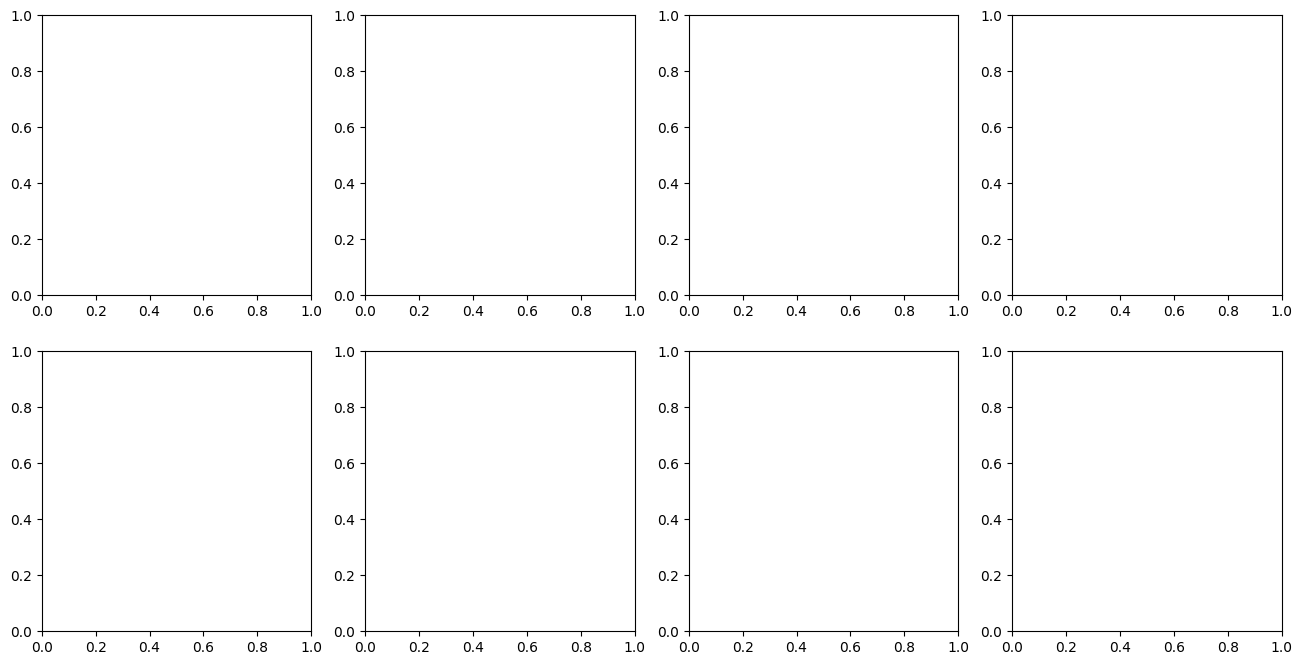

In [39]:
colors = {'nn': '#5B9BD5', '2opt': '#ED7D31', 'gnn': '#70AD47', 'gnn_2opt': '#FFC000'}

plot_sizes = [n for n in sorted(all_results.keys()) if n != 10]
n_plots    = len(plot_sizes)

if n_plots == 0:
    print('No variable-size results to plot — run Section 4 first.')
else:
    ncols = min(n_plots, 4)
    nrows = (n_plots + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(4 * ncols, 4 * nrows),
                             squeeze=False)
    axes_flat = axes.flat

    for ax, N in zip(axes_flat, plot_sizes):
        res    = all_results[N]
        nn_len = res['nn']
        gaps   = {}
        for m in METHODS:
            v = res[m]
            gaps[m] = (v / nn_len - 1.0) * 100.0 if not np.isnan(v) else None

        labels = [m for m in METHODS if gaps[m] is not None]
        vals   = [gaps[m] for m in labels]
        bars   = ax.bar(labels, vals,
                        color=[colors[m] for m in labels],
                        edgecolor='black', linewidth=0.7)
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
        ax.set_title(f'n = {N}  — gap vs NN', fontsize=11)
        ax.set_ylabel('Gap (%)')
        ax.set_xlabel('Method')
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    v + (0.3 if v >= 0 else -0.8),
                    f'{v:+.1f}%', ha='center', va='bottom', fontsize=8)

    # Hide unused axes
    for ax in list(axes_flat)[n_plots:]:
        ax.set_visible(False)

    plt.suptitle('TSP Benchmark — GNN vs baselines (variable size)', fontsize=13,
                 fontweight='bold')
    plt.tight_layout()
    os.makedirs('figures/benchmark', exist_ok=True)
    plt.savefig('figures/benchmark/tsp_gap_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved figures/benchmark/tsp_gap_comparison.png')

## Section 6 — Tour visualisation

Visual comparison of all methods on a single n=20 instance.

In [ ]:
coords_viz = random_instance(20, seed=7)
tours = {
    'nn':      run_nn(coords_viz),
    '2opt':    run_2opt(coords_viz),
    'gnn':     run_gnn(coords_viz),
    'gnn+2opt': run_gnn_2opt(coords_viz),
}

def draw_tour(ax, coords, tour, color, title):
    xy = coords.numpy()
    closed = tour + [tour[0]]
    xs = xy[closed, 0]
    ys = xy[closed, 1]
    ax.plot(xs, ys, '-o', color=color, markersize=5, linewidth=1.4)
    ax.plot(xy[0, 0], xy[0, 1], 's', color='black', markersize=9, zorder=5, label='Depot')
    length = tour_length(coords, tour)
    ax.set_title(f'{title}\nlen={length:.4f}', fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
palette = ['#5B9BD5', '#ED7D31', '#70AD47', '#FFC000']
for ax, (name, tour), color in zip(axes, tours.items(), palette):
    draw_tour(ax, coords_viz, tour, color, name)

plt.suptitle('TSP — Tour comparison (n=20, seed=7)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/benchmark/tsp_tour_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/benchmark/tsp_tour_comparison.png')

## Section 7 — Model overview figure

Four-panel overview on a seed-0, n=8 instance:
1. **BCE training loss curve** — from `model/losses.npy`
2. **Ground-truth edge matrix** $y_{ij}$ — brute-force optimal labels
3. **Predicted probabilities** $\hat{p}_{ij}$ — GNN forward pass
4. **Tour comparison** — optimal (green) vs GNN greedy (blue)

Saved to `figures/demo_overview.png` (referenced in the technical report).

In [ ]:
# ── Section 7: demo_overview.png ──────────────────────────────────────────────
# Requires: model/gnn_{SIZE}.pt  (loaded in Section 1)
#           model/losses.npy     (saved automatically by train.py alongside weights)

DEMO_N    = 8
DEMO_SEED = 0

coords_demo = random_instance(DEMO_N, seed=DEMO_SEED)

# Panel (ii): ground-truth labels (brute-force optimal for n=8)
y_labels = optimal_tour_labels(coords_demo)   # (n, n) float tensor

# Panel (iii): GNN predicted probabilities
with torch.no_grad():
    p_hat = model_tsp(coords_demo.to(DEVICE)).cpu()   # (n, n)

# Panel (iv): tours
opt_t, opt_len = optimal_tour(coords_demo)
gnn_tour       = greedy_decode(p_hat, start=0)
gnn_len        = tour_length(coords_demo, gnn_tour)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# (i) Loss curve
ax = axes[0]
losses_path = 'model/losses.npy'
if os.path.exists(losses_path):
    losses_arr = np.load(losses_path)
    ax.plot(losses_arr, linewidth=1.2, color='#2176AE')
    ax.set_xlabel('Step')
    ax.set_ylabel('BCE loss')
    ax.set_title('(i) Training loss')
else:
    ax.text(0.5, 0.5, 'losses.npy not found\n(run train.py first)',
            ha='center', va='center', transform=ax.transAxes, fontsize=9,
            color='grey')
    ax.set_title('(i) Training loss')
    ax.set_xticks([]); ax.set_yticks([])

# (ii) Ground-truth edge matrix
ax = axes[1]
im = ax.imshow(y_labels.numpy(), cmap='Blues', vmin=0, vmax=1)
ax.set_title(r'(ii) Ground truth $y_{ij}$')
ax.set_xlabel('node j'); ax.set_ylabel('node i')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# (iii) Predicted probabilities
ax = axes[2]
im2 = ax.imshow(p_hat.numpy(), cmap='Oranges', vmin=0, vmax=1)
ax.set_title(r'(iii) Predicted $\hat{p}_{ij}$')
ax.set_xlabel('node j'); ax.set_ylabel('node i')
plt.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)

# (iv) Tour comparison
ax = axes[3]
xy = coords_demo.numpy()

def _plot_tour(ax, xy, tour, color, label):
    closed = tour + [tour[0]]
    ax.plot(xy[closed, 0], xy[closed, 1], '-o', color=color,
            markersize=5, linewidth=1.5, label=label)

_plot_tour(ax, xy, opt_t,    '#2CA02C', f'Optimal ({opt_len:.3f})')
_plot_tour(ax, xy, gnn_tour, '#1F77B4', f'GNN ({gnn_len:.3f})')
ax.plot(xy[0, 0], xy[0, 1], 's', color='black', markersize=9, zorder=5)
ax.set_title(f'(iv) Tour comparison  n={DEMO_N}')
ax.legend(fontsize=8, loc='upper right')
ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('GNN — Model overview (seed=0, n=8)', fontsize=13, fontweight='bold')
plt.tight_layout()

os.makedirs('figures', exist_ok=True)
plt.savefig('figures/demo_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/demo_overview.png')